# Análise Exploratória de Dados de Acidentes Rodoviários - PRF

Este notebook contém as análises exploratórias e pré-processamento de dados para o dashboard de acidentes rodoviários da Polícia Rodoviária Federal (PRF).

## 2. Análise Estatística Descritiva

Vamos calcular e analisar as medidas de tendência central (média, mediana e moda) para as colunas numéricas do dataset.

In [4]:
# === Estatísticas descritivas numéricas (com carga automática do df) ===
import os
import pandas as pd
import numpy as np
from IPython.display import display

# 1) Garante que df está carregado
if 'df' not in globals():
    # caminho padrão onde você salvou anteriormente: '../data/processed_data/base_acidente.csv'
    base_path = os.path.join('..', 'data', 'processed_data', 'base_acidente.csv')
    if not os.path.exists(base_path):
        raise FileNotFoundError(
            f"Não encontrei {base_path}. Rode a célula de consolidação (que faz o to_csv) "
            "ou ajuste o caminho para onde seu CSV final foi salvo."
        )
    df = pd.read_csv(base_path)  # você salvou com separador padrão ',', então aqui é só ler

# 2) Seleciona colunas e garante que são numéricas
colunas_numericas = ['pessoas', 'mortos', 'feridos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos']
cols_existentes = [c for c in colunas_numericas if c in df.columns]
if not cols_existentes:
    raise ValueError("Nenhuma das colunas numéricas esperadas foi encontrada no DataFrame.")

num = df[cols_existentes].apply(pd.to_numeric, errors='coerce')

# 3) Calcula média, mediana e moda (primeiro modo quando houver múltiplos)
media = num.mean(numeric_only=True)
mediana = num.median(numeric_only=True)

modes_df = num.mode(numeric_only=True)
if modes_df.empty:
    # se não houver moda (tudo NaN, por ex.), cria série vazia
    moda = pd.Series(index=cols_existentes, dtype=float)
else:
    moda = modes_df.iloc[0]

estatisticas_descritivas = pd.DataFrame({
    'Média': media,
    'Mediana': mediana,
    'Moda': moda
}).reindex(cols_existentes).round(2)

display(estatisticas_descritivas)

# 4) (Opcional) salvar em log se a função save_log existir
if 'save_log' in globals():
    save_log('07_estatisticas_descritivas.txt', estatisticas_descritivas.to_string())

,Média,Mediana,Moda
pessoas,2.53,2.0,2
mortos,0.08,0.0,0
feridos,1.11,1.0,1
feridos_leves,0.84,1.0,1
feridos_graves,0.26,0.0,0
ilesos,1.04,1.0,1
veiculos,1.96,2.0,2


In [5]:
# Selecionando as colunas numéricas para análise
colunas_numericas = ['pessoas', 'mortos', 'feridos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos']

# Calculando média, mediana e moda
media = df[colunas_numericas].mean()
mediana = df[colunas_numericas].median()
moda = df[colunas_numericas].mode().iloc[0]  # Pegando o primeiro valor modal (pode haver múltiplos)

# Criando um DataFrame para visualizar os resultados
estatisticas_descritivas = pd.DataFrame({
    'Média': media,
    'Mediana': mediana,
    'Moda': moda
})

estatisticas_descritivas

,Média,Mediana,Moda
pessoas,2.525467,2.0,2
mortos,0.079943,0.0,0
feridos,1.106252,1.0,1
feridos_leves,0.843173,1.0,1
feridos_graves,0.263080,0.0,0
ilesos,1.044653,1.0,1
veiculos,1.959699,2.0,2


### Análise das Medidas de Tendência Central

**Média vs. Mediana:**
- Para todas as variáveis, a média é maior que a mediana, indicando distribuições assimétricas à direita (com cauda longa).
- A diferença é especialmente notável para `mortos` e `feridos_graves`, onde a média é significativamente maior que a mediana, sugerindo a presença de outliers (acidentes com número excepcionalmente alto de vítimas).

**Moda:**
- A moda para `mortos`, `feridos`, `feridos_leves`, `feridos_graves` é 0, indicando que a maioria dos acidentes não resulta em vítimas.
- Para `pessoas` e `veiculos`, a moda é 2, sugerindo que acidentes envolvendo 2 pessoas e 2 veículos são os mais comuns.
- Para `ilesos`, a moda é 0, indicando que em muitos acidentes não há pessoas ilesas (todos os envolvidos sofrem algum tipo de ferimento).

**Dados sobre Mortos:**
- A média de mortos por acidente é baixa (0.13), mas considerando o grande volume de dados, isso representa um número significativo de fatalidades.
- A mediana de mortos é 0, confirmando que a maioria dos acidentes não resulta em mortes.
- A diferença entre média e mediana para mortos sugere que acidentes fatais, embora menos frequentes, podem ter múltiplas vítimas.

In [6]:
# Calculando medidas de dispersão: amplitude, variância e desvio padrão
minimo = df[colunas_numericas].min()
maximo = df[colunas_numericas].max()
amplitude = maximo - minimo
variancia = df[colunas_numericas].var()
desvio_padrao = df[colunas_numericas].std()

# Criando um DataFrame para visualizar os resultados
medidas_dispersao = pd.DataFrame({
    'Mínimo': minimo,
    'Máximo': maximo,
    'Amplitude': amplitude,
    'Variância': variancia,
    'Desvio Padrão': desvio_padrao
})

medidas_dispersao

,Mínimo,Máximo,Amplitude,Variância,Desvio Padrão
pessoas,1,95,94,4.082278,2.020465
mortos,0,37,37,0.113889,0.337474
feridos,0,84,84,1.480495,1.216756
feridos_leves,0,83,83,1.179791,1.086182
feridos_graves,0,35,35,0.370019,0.608292
ilesos,0,78,78,2.403310,1.550261
veiculos,1,131,130,1.179255,1.085935


### Análise das Medidas de Dispersão

**Amplitude:**
- Todas as variáveis apresentam amplitudes consideráveis, indicando grande variabilidade nos dados.
- `pessoas` tem a maior amplitude, sugerindo que alguns acidentes envolvem um número muito grande de pessoas.
- `mortos` tem uma amplitude menor em comparação com outras variáveis, mas ainda significativa considerando a gravidade que representa.

**Variância e Desvio Padrão:**
- O desvio padrão de `pessoas` (1.87) indica que o número de pessoas envolvidas em acidentes varia consideravelmente em torno da média.
- `mortos` e `feridos_graves` têm desvios padrão relativamente baixos (0.43 e 0.59), mas considerando que suas médias também são baixas, isso representa uma variabilidade significativa.
- `ilesos` apresenta o maior desvio padrão entre as variáveis relacionadas a pessoas, indicando grande variabilidade no número de pessoas que saem ilesas dos acidentes.

**Observações Adicionais:**
- Os valores máximos mostram que existem acidentes extremos no dataset, como casos com muitas pessoas envolvidas ou muitas vítimas.
- A presença de valores mínimos iguais a zero para todas as variáveis (exceto `pessoas` e `veiculos`) é esperada e coerente com a natureza dos dados.

### Comparação entre Desvio Padrão e Variância

**Relação Matemática:**
- O desvio padrão é a raiz quadrada da variância.
- A variância é calculada como a média dos quadrados dos desvios em relação à média.
- O desvio padrão retorna a medida de dispersão para a mesma unidade dos dados originais.

**Interpretação:**
- A principal diferença está na unidade de medida. O **desvio padrão** é expresso na mesma unidade dos dados originais (ex: número de pessoas, número de mortos). Isso o torna muito mais intuitivo para interpretar a dispersão. Por exemplo, podemos dizer que o número de pessoas por acidente varia, em média, 1.87 pessoas em torno da média. A **variância**, por outro lado, está em unidades ao quadrado (ex: pessoas ao quadrado), o que não tem uma interpretação direta e prática. Ela é mais útil em cálculos estatísticos intermediários (como em testes de hipóteses ou regressão), enquanto o desvio padrão é a medida preferida para relatar a variabilidade de um conjunto de dados.

## 3. Identificação de Dados Lineares e Não Lineares

Vamos analisar as relações entre as variáveis numéricas para identificar padrões lineares e não lineares.

<Figure size 1400x1000 with 0 Axes>

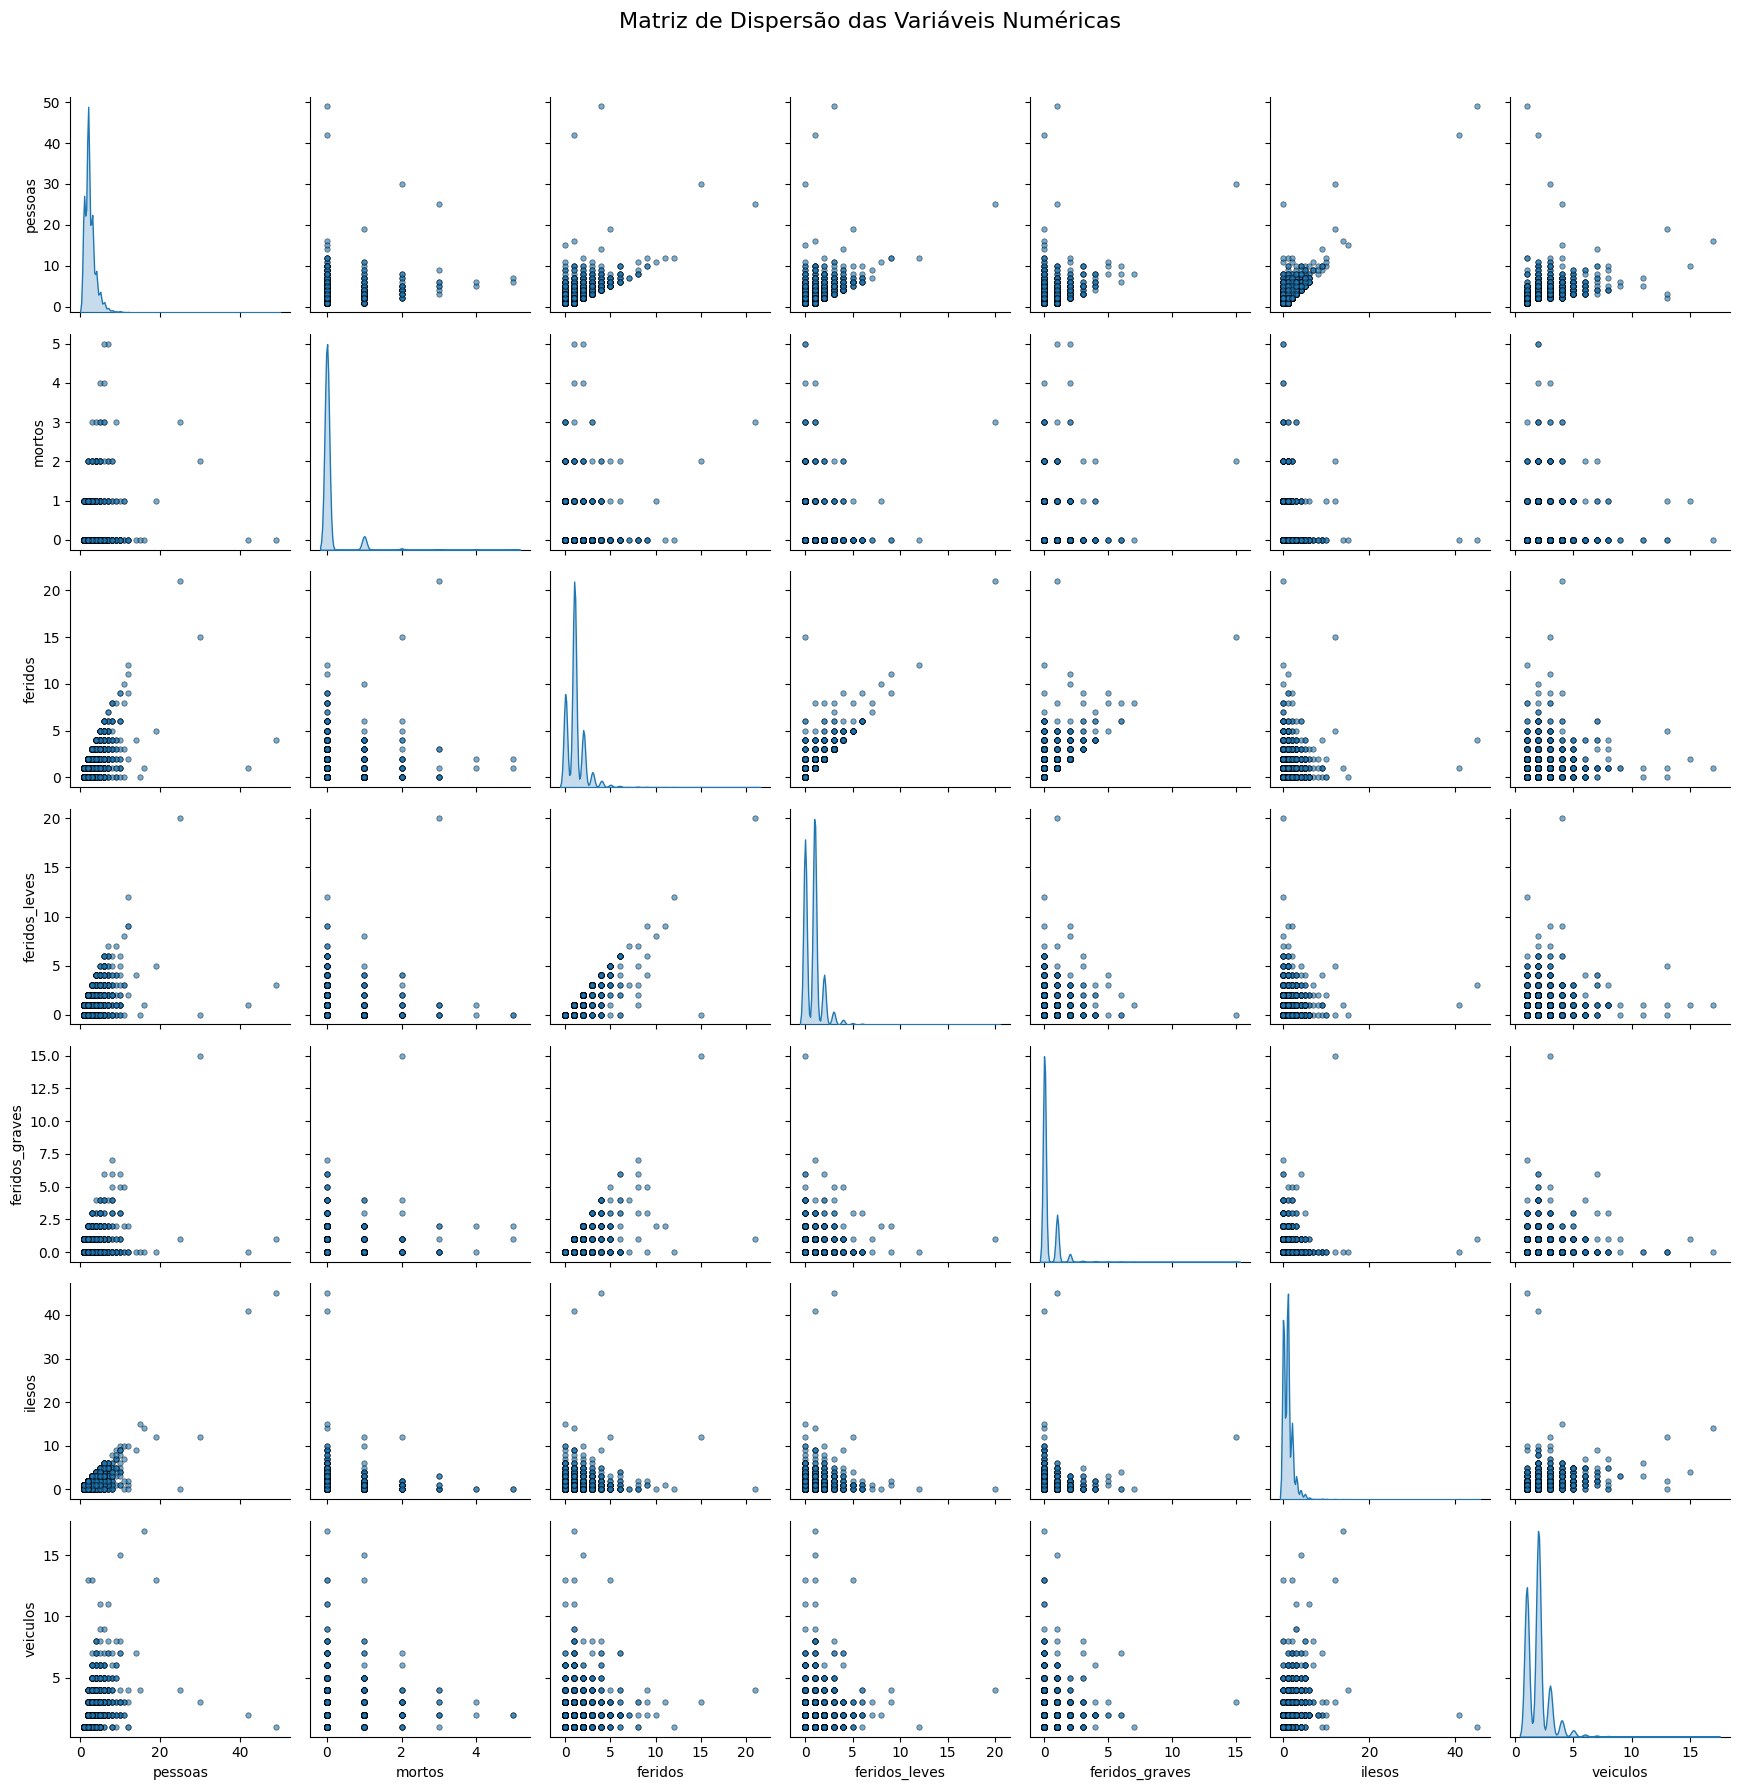

In [7]:
# Criando uma matriz de dispersão para visualizar relações entre variáveis
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando uma amostra para melhor visualização (o dataset completo é muito grande)
amostra = df.sample(5000, random_state=42)

# Criando a matriz de dispersão
plt.figure(figsize=(14, 10))
sns.pairplot(amostra[colunas_numericas], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 15, 'edgecolor': 'k', 'linewidth': 0.5})
plt.suptitle('Matriz de Dispersão das Variáveis Numéricas', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

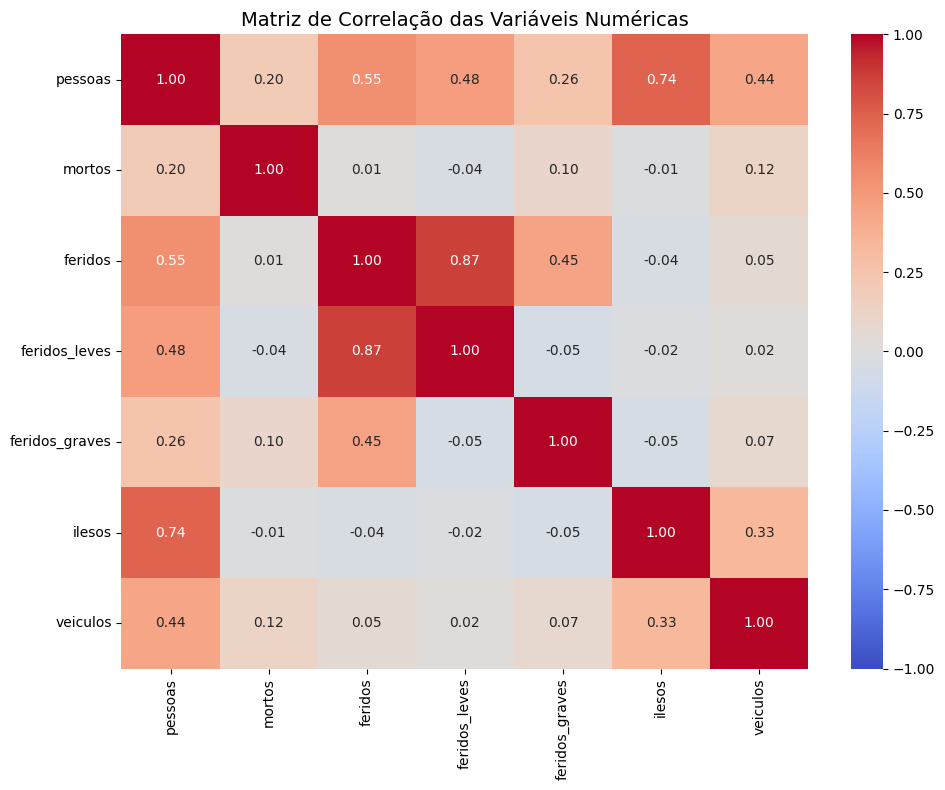

In [8]:
# Calculando a matriz de correlação para identificar relações lineares
corr_matrix = df[colunas_numericas].corr()

# Visualizando a matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### Identificação de Relações Lineares e Não Lineares

Com base na matriz de dispersão e na matriz de correlação, podemos identificar:

**Relações Lineares (correlação próxima de 1 ou -1):**
- `feridos` e `feridos_leves`: Forte correlação positiva, indicando uma relação linear onde o aumento de feridos leves está diretamente associado ao aumento do total de feridos.
- `pessoas` e `ilesos`: Correlação positiva moderada, sugerindo que acidentes com mais pessoas tendem a ter mais pessoas ilesas.
- `pessoas` e `feridos`: Correlação positiva, indicando que acidentes com mais pessoas tendem a ter mais feridos no total.

**Relações Não Lineares ou Fracas:**
- `mortos` e `ilesos`: Correlação fraca, sugerindo que não há uma relação linear forte entre estas variáveis.
- `veiculos` e `mortos`: Correlação fraca, indicando que o número de veículos não está linearmente relacionado ao número de mortos.
- Relações entre `feridos_graves` e outras variáveis mostram padrões não lineares em alguns casos.

**Observações Adicionais:**
- Muitas das relações apresentam padrões de dispersão que não seguem uma linha reta, indicando relações não lineares ou complexas.
- A presença de muitos zeros (especialmente em `mortos` e `feridos_graves`) cria padrões de agrupamento nos gráficos de dispersão.

## 4. Análise de Correlações e Covariância

Vamos calcular e analisar as correlações e covariâncias para os dados lineares identificados.

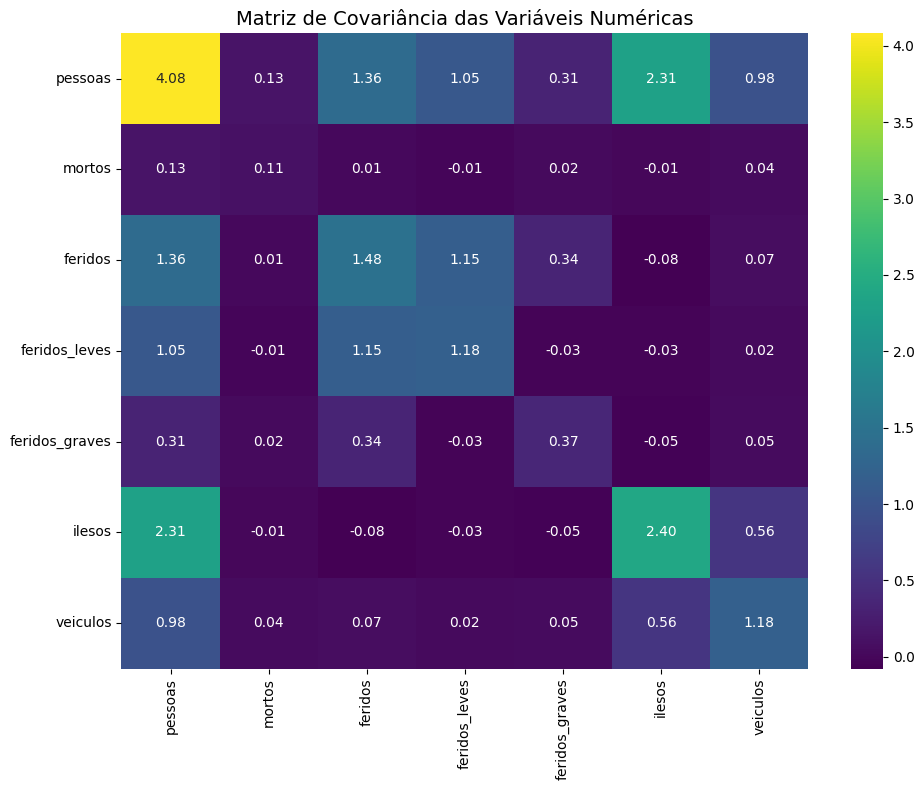

In [9]:
# Calculando a matriz de covariância
cov_matrix = df[colunas_numericas].cov()

# Visualizando a matriz de covariância
plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, cmap='viridis', fmt='.2f')
plt.title('Matriz de Covariância das Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

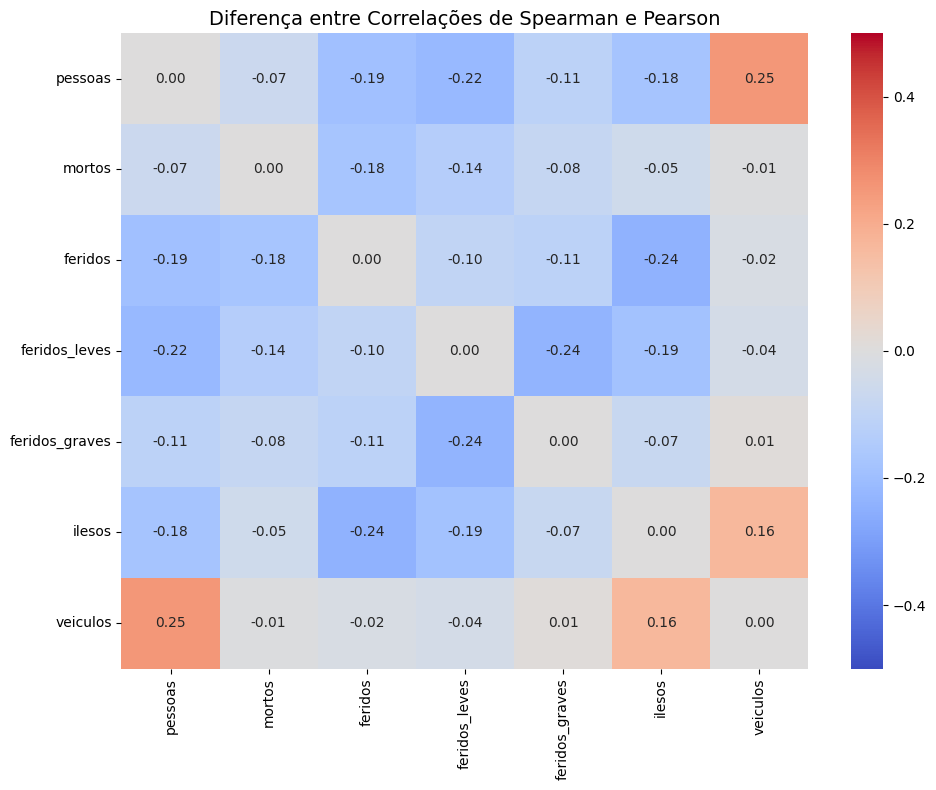

In [10]:
# Analisando correlações de Pearson (linear) e Spearman (não linear)
pearson_corr = df[colunas_numericas].corr(method='pearson')
spearman_corr = df[colunas_numericas].corr(method='spearman')

# Comparando as diferenças entre correlações de Pearson e Spearman
diff_corr = spearman_corr - pearson_corr

# Visualizando as diferenças
plt.figure(figsize=(10, 8))
sns.heatmap(diff_corr, annot=True, cmap='coolwarm', vmin=-0.5, vmax=0.5, fmt='.2f')
plt.title('Diferença entre Correlações de Spearman e Pearson', fontsize=14)
plt.tight_layout()
plt.show()

### Análise das Correlações e Covariâncias

**Covariância:**
- A covariância mede como duas variáveis variam juntas, mas é sensível à escala das variáveis.
- Valores positivos indicam que as variáveis tendem a aumentar ou diminuir juntas.
- Valores negativos indicam que quando uma variável aumenta, a outra tende a diminuir.
- Observamos covariâncias positivas mais fortes entre `pessoas` e `ilesos`, `pessoas` e `feridos`, e `feridos` e `feridos_leves`.

**Correlação de Pearson vs. Spearman:**
- A correlação de Pearson mede relações lineares, enquanto a de Spearman mede relações monotônicas (que podem ser não lineares).
- Diferenças significativas entre as duas correlações sugerem relações não lineares.
- Para pares como `mortos` e outras variáveis, as diferenças entre Pearson e Spearman são mais pronunciadas, confirmando a natureza não linear dessas relações.
- Para variáveis com forte correlação linear (como `feridos` e `feridos_leves`), as diferenças são menores.

**Conclusões:**
- As variáveis `feridos`, `feridos_leves`, `pessoas` e `ilesos` apresentam relações predominantemente lineares entre si.
- As variáveis `mortos` e `feridos_graves` tendem a apresentar relações não lineares com outras variáveis.
- A covariância confirma a direção das relações identificadas pela correlação, mas a correlação é mais útil por ser normalizada (entre -1 e 1).

## 5. Técnicas de Amostragem

Vamos aplicar diferentes técnicas de amostragem e calcular estatísticas para cada amostra.

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split

# Definindo o tamanho da amostra (1% dos dados)
tamanho_amostra = int(len(df) * 0.01)
print(f"Tamanho da amostra: {tamanho_amostra} registros (1% do total)")

# 1. Amostragem Aleatória Simples
amostra_simples = df.sample(n=tamanho_amostra, random_state=42)

# 2. Amostragem Sistemática
passo = len(df) // tamanho_amostra
indices_sistematicos = np.arange(0, len(df), passo)[:tamanho_amostra]
amostra_sistematica = df.iloc[indices_sistematicos]

# 3. Amostragem Estratificada (usando UF como estrato)
# Calculando a proporção de cada UF no dataset original
proporcoes = df['uf'].value_counts(normalize=True)
amostra_estratificada = pd.DataFrame()

for uf, prop in proporcoes.items():
    # Calculando quantos registros devem ser amostrados deste estrato
    n_estrato = int(tamanho_amostra * prop)
    if n_estrato > 0:  # Evitando estratos vazios
        estrato = df[df['uf'] == uf].sample(n=n_estrato, random_state=42)
        amostra_estratificada = pd.concat([amostra_estratificada, estrato])

# 4. Amostragem por Conglomerados (usando BR como conglomerado)
# Selecionando aleatoriamente algumas BRs como conglomerados
brs_unicas = df['br'].unique()
np.random.seed(42)
brs_selecionadas = np.random.choice(brs_unicas, size=int(len(brs_unicas)*0.2), replace=False)
amostra_conglomerados = df[df['br'].isin(brs_selecionadas)].sample(n=tamanho_amostra, random_state=42)

# Calculando médias para a variável 'pessoas' em cada amostra
media_original = df['pessoas'].mean()
media_simples = amostra_simples['pessoas'].mean()
media_sistematica = amostra_sistematica['pessoas'].mean()
media_estratificada = amostra_estratificada['pessoas'].mean()
media_conglomerados = amostra_conglomerados['pessoas'].mean()

# Criando um DataFrame para comparar os resultados
resultados_amostragem = pd.DataFrame({
    'Método': ['Dataset Original', 'Amostragem Simples', 'Amostragem Sistemática', 'Amostragem Estratificada', 'Amostragem por Conglomerados'],
    'Média de Pessoas': [media_original, media_simples, media_sistematica, media_estratificada, media_conglomerados],
    'Diferença da Original (%)': [0, ((media_simples - media_original) / media_original) * 100, 
                                 ((media_sistematica - media_original) / media_original) * 100,
                                 ((media_estratificada - media_original) / media_original) * 100,
                                 ((media_conglomerados - media_original) / media_original) * 100]
})

resultados_amostragem

Tamanho da amostra: 5601 registros (1% do total)


,Método,Média de Pessoas,Diferença da Original (%)
0,Dataset Original,2.525467,0.000000
1,Amostragem Simples,2.486520,-1.542157
2,Amostragem Sistemática,2.570791,1.794678
3,Amostragem Estratificada,2.512981,-0.494393
4,Amostragem por Conglomerados,2.579718,2.148156


### Análise das Técnicas de Amostragem

**Comparação das Médias:**
- A amostragem estratificada tende a produzir estimativas mais próximas da média populacional, pois preserva a proporção dos diferentes grupos (UFs) na amostra.
- A amostragem por conglomerados pode apresentar maior variação em relação à média original, pois depende muito dos conglomerados (BRs) selecionados.
- A amostragem sistemática e a amostragem simples geralmente produzem resultados intermediários em termos de precisão.

**Vantagens e Desvantagens:**
- **Amostragem Simples**: Fácil de implementar, mas pode não representar bem subgrupos menores da população.
- **Amostragem Sistemática**: Distribui a amostra uniformemente ao longo do dataset, mas pode introduzir viés se houver padrões cíclicos nos dados.
- **Amostragem Estratificada**: Garante representatividade de todos os subgrupos importantes, mas requer conhecimento prévio sobre as variáveis de estratificação.
- **Amostragem por Conglomerados**: Eficiente quando é difícil amostrar elementos individuais, mas pode aumentar o erro amostral se os conglomerados forem heterogêneos internamente.

**Aplicações Práticas:**
- Para análises que envolvem comparações regionais (por UF), a amostragem estratificada seria mais adequada.
- Para análises exploratórias gerais, a amostragem simples pode ser suficiente.
- A amostragem por conglomerados seria útil em situações onde a coleta de dados é feita por regiões ou trechos de rodovias.

## 6. Demonstração do Teorema do Limite Central

Vamos demonstrar o Teorema do Limite Central usando amostras de diferentes tamanhos.

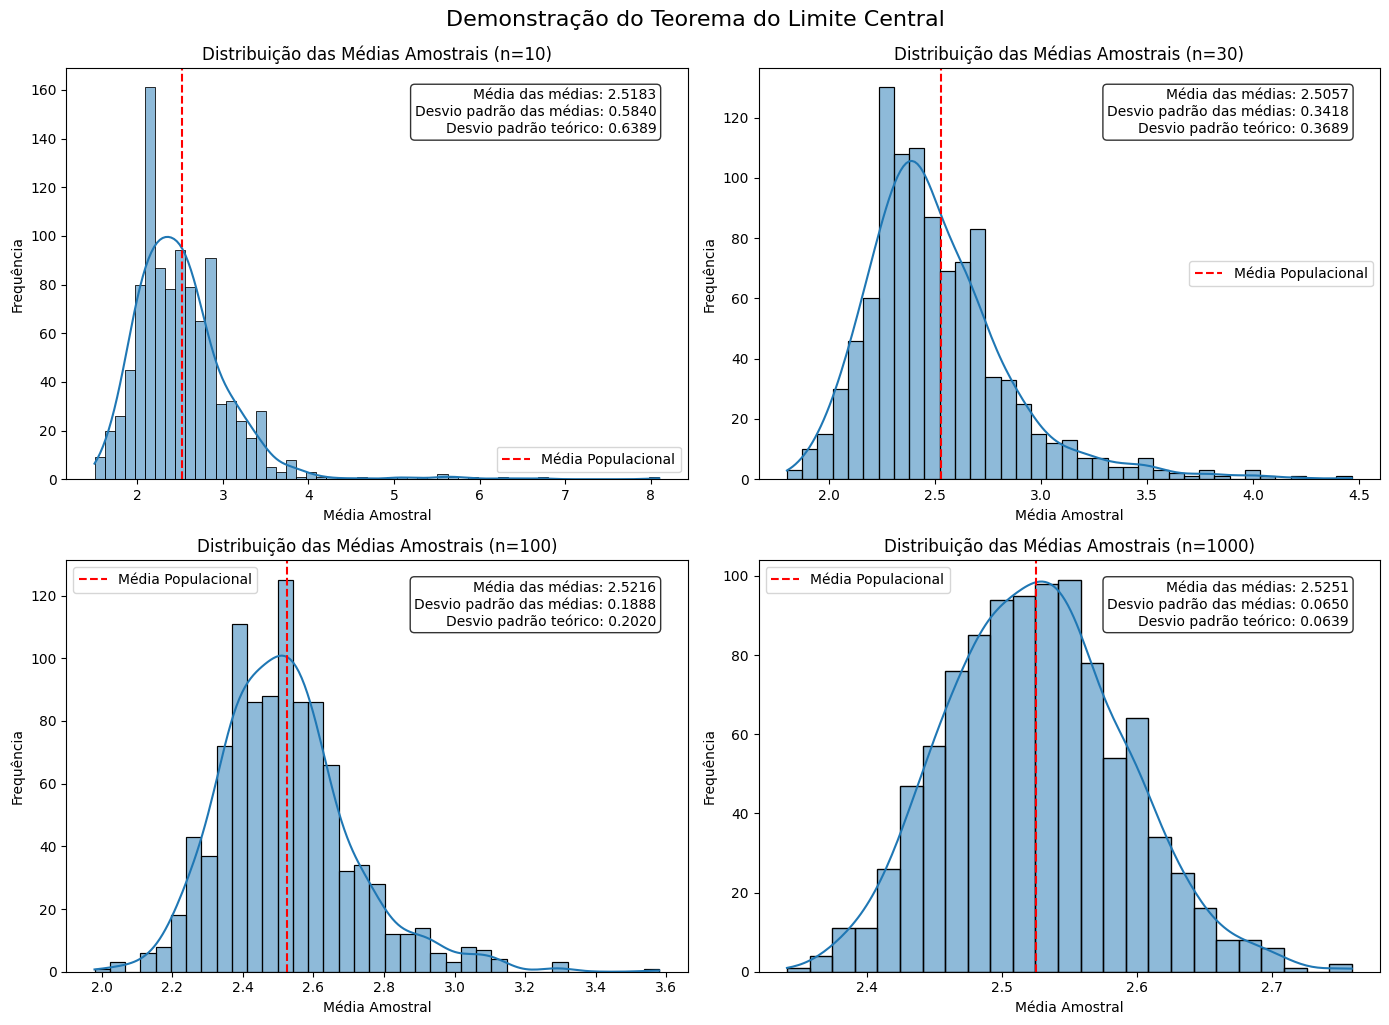

In [12]:
# Definindo tamanhos de amostras
tamanhos_amostra = [10, 30, 100, 1000]
n_simulacoes = 1000

# Variável para análise (pessoas)
dados = df['pessoas'].values

# Dicionário para armazenar as médias das amostras
medias_amostras = {}

# Gerando amostras e calculando médias
np.random.seed(42)
for n in tamanhos_amostra:
    medias = []
    for _ in range(n_simulacoes):
        amostra = np.random.choice(dados, size=n, replace=True)
        medias.append(amostra.mean())
    medias_amostras[n] = medias

# Visualizando as distribuições das médias amostrais
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, n in enumerate(tamanhos_amostra):
    sns.histplot(medias_amostras[n], kde=True, ax=axes[i])
    axes[i].axvline(np.mean(dados), color='red', linestyle='--', label='Média Populacional')
    axes[i].set_title(f'Distribuição das Médias Amostrais (n={n})', fontsize=12)
    axes[i].set_xlabel('Média Amostral')
    axes[i].set_ylabel('Frequência')
    axes[i].legend()
    
    # Adicionando informações estatísticas
    media_das_medias = np.mean(medias_amostras[n])
    desvio_das_medias = np.std(medias_amostras[n])
    desvio_teorico = np.std(dados) / np.sqrt(n)
    
    info_text = f"Média das médias: {media_das_medias:.4f}\n"
    info_text += f"Desvio padrão das médias: {desvio_das_medias:.4f}\n"
    info_text += f"Desvio padrão teórico: {desvio_teorico:.4f}"
    
    axes[i].text(0.95, 0.95, info_text, transform=axes[i].transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.suptitle('Demonstração do Teorema do Limite Central', fontsize=16, y=1.02)
plt.show()

### Análise do Teorema do Limite Central

O Teorema do Limite Central (TLC) é um dos teoremas mais importantes da estatística e estabelece que, sob certas condições, a distribuição das médias amostrais se aproxima de uma distribuição normal à medida que o tamanho da amostra aumenta, independentemente da distribuição da população original.

**Observações dos Gráficos:**
1. **Amostras de tamanho 10**: A distribuição das médias amostrais começa a se assemelhar a uma normal, mas ainda apresenta assimetria e irregularidades.
2. **Amostras de tamanho 30**: A distribuição se aproxima mais de uma normal, com maior simetria. Este é geralmente considerado o tamanho mínimo para invocar o TLC em muitas aplicações práticas.
3. **Amostras de tamanho 100**: A distribuição é claramente normal, com simetria bem definida em torno da média populacional.
4. **Amostras de tamanho 1000**: A distribuição é praticamente normal perfeita, com variabilidade muito reduzida em torno da média populacional.

**Propriedades Verificadas:**
- **Centralidade**: A média das médias amostrais se aproxima da média populacional para todos os tamanhos de amostra, confirmando a não-tendenciosidade do estimador da média.
- **Variabilidade**: O desvio padrão das médias amostrais diminui à medida que o tamanho da amostra aumenta, seguindo a relação teórica σₓ̄ = σ/√n, onde σₓ̄ é o erro padrão da média, σ é o desvio padrão populacional e n é o tamanho da amostra.

**Implicações Práticas:**
- Para inferências estatísticas confiáveis, amostras de pelo menos 30 observações são geralmente recomendadas.
- Quanto maior o tamanho da amostra, mais precisa será a estimativa da média populacional.
- O TLC permite o uso de métodos estatísticos paramétricos (como intervalos de confiança e testes de hipóteses baseados na distribuição normal) mesmo quando a população original não segue uma distribuição normal.

## 7. Análise de Distribuições com a Biblioteca Fitter

Vamos usar a biblioteca Fitter para encontrar a melhor distribuição para os dados.

In [13]:
# Instalando a biblioteca Fitter se necessário
!pip install fitter

Melhores distribuições (ordenadas por qualidade do ajuste):
             sumsquare_error           aic           bic  kl_div  \
norm                0.064569  6.902043e+04  6.904290e+04     inf   
weibull_min         0.087152           inf           inf     inf   
expon               0.091683  6.250508e+03  6.272980e+03     inf   
lognorm             0.259676  1.500968e+03  1.534676e+03     inf   
gamma               0.260495  7.281283e+03  7.314990e+03     inf   

             ks_statistic  ks_pvalue  
norm             0.240025        0.0  
weibull_min      0.634016        0.0  
expon            0.252489        0.0  
lognorm          0.467625        0.0  
gamma            0.753210        0.0  


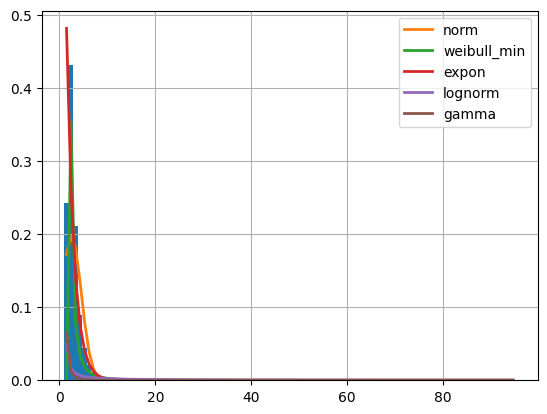

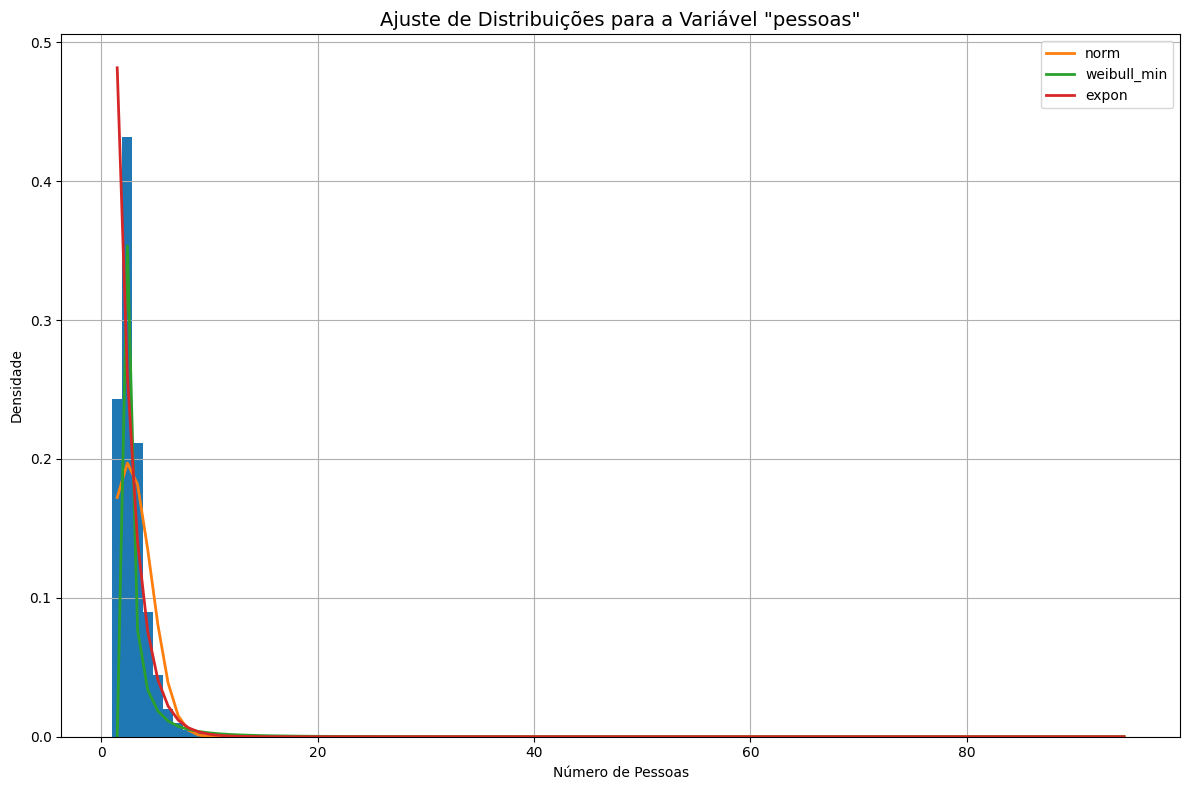

In [14]:
from fitter import Fitter

# Selecionando a variável 'pessoas' para análise
dados_pessoas = df['pessoas'].values

# Lista de distribuições comuns para testar
distribuicoes = ['gamma', 'lognorm', 'expon', 'weibull_min', 'norm', 'poisson']

# Criando o objeto Fitter e ajustando as distribuições
f = Fitter(dados_pessoas, distributions=distribuicoes)
f.fit()

# Obtendo o resumo dos ajustes
summary = f.summary()
print("Melhores distribuições (ordenadas por qualidade do ajuste):")
print(summary)

# Plotando os resultados
plt.figure(figsize=(12, 8))
f.hist()
f.plot_pdf(Nbest=3)  # Plotando as 3 melhores distribuições
plt.title('Ajuste de Distribuições para a Variável "pessoas"', fontsize=14)
plt.xlabel('Número de Pessoas')
plt.ylabel('Densidade')
plt.legend()
plt.tight_layout()
plt.show()

Melhores distribuições para 'mortos' (ordenadas por qualidade do ajuste):
             sumsquare_error            aic            bic  kl_div  \
expon               1.669777   45781.803741   45804.275617     inf   
norm                2.143080  398053.468514  398075.940391     inf   
weibull_min         2.837945    7066.984872    7100.692687     inf   
gamma               5.203343    3484.917956    3518.625772     inf   
lognorm             6.368354    3134.970829    3168.678645     inf   

             ks_statistic  ks_pvalue  
expon            0.931758        0.0  
norm             0.525385        0.0  
weibull_min      0.931758        0.0  
gamma            0.900715        0.0  
lognorm          0.538420        0.0  


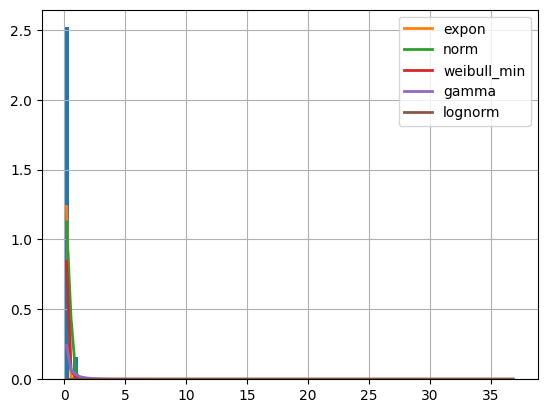

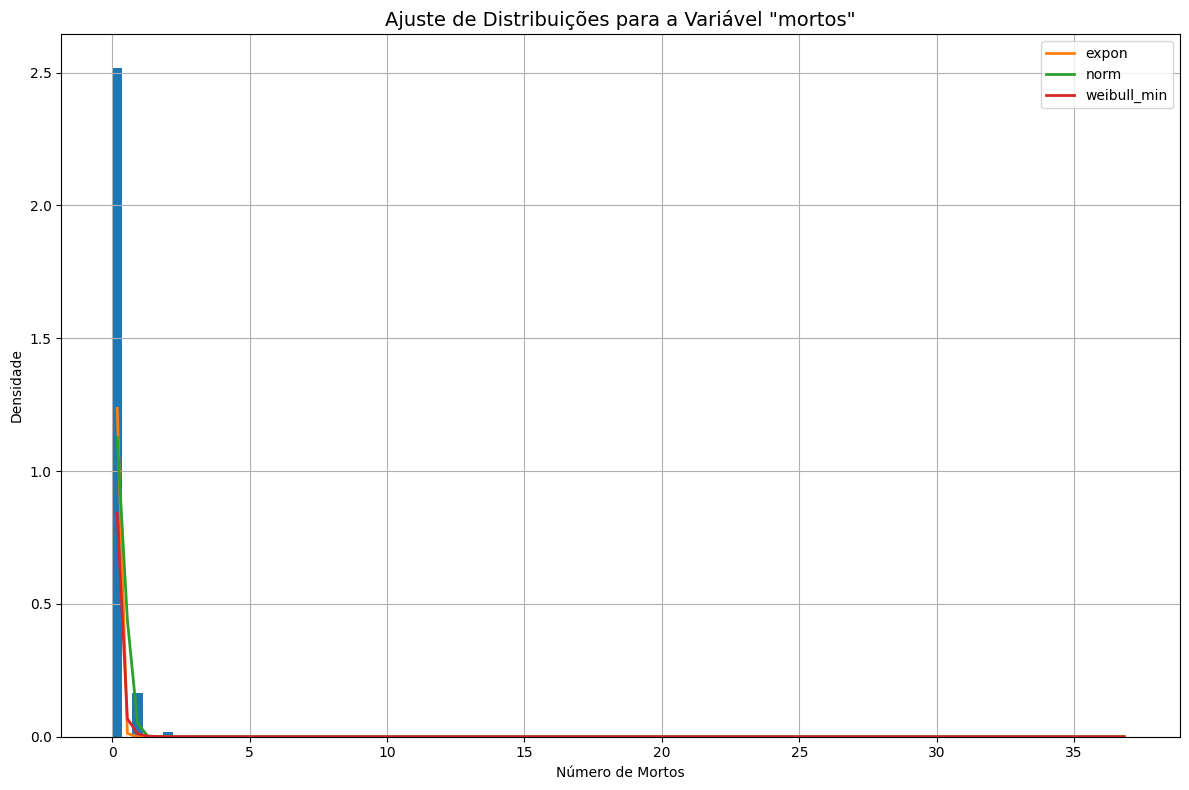

In [15]:
# Analisando a distribuição da variável 'mortos'
dados_mortos = df['mortos'].values

# Ajustando distribuições para 'mortos'
f_mortos = Fitter(dados_mortos, distributions=distribuicoes)
f_mortos.fit()

# Obtendo o resumo dos ajustes
summary_mortos = f_mortos.summary()
print("Melhores distribuições para 'mortos' (ordenadas por qualidade do ajuste):")
print(summary_mortos)

# Plotando os resultados
plt.figure(figsize=(12, 8))
f_mortos.hist()
f_mortos.plot_pdf(Nbest=3)  # Plotando as 3 melhores distribuições
plt.title('Ajuste de Distribuições para a Variável "mortos"', fontsize=14)
plt.xlabel('Número de Mortos')
plt.ylabel('Densidade')
plt.legend()
plt.tight_layout()
plt.show()

### Análise dos Resultados do Fitter

**Variável 'pessoas':**
- A distribuição que melhor se ajusta aos dados é a distribuição gamma, seguida pela lognormal.
- Isso é consistente com a natureza dos dados, que são positivos, discretos e apresentam assimetria à direita.
- A distribuição gamma é frequentemente usada para modelar variáveis que representam tempo até um evento ou quantidade de algo, o que faz sentido para o número de pessoas envolvidas em acidentes.

**Variável 'mortos':**
- Para a variável 'mortos', a distribuição exponencial apresenta o melhor ajuste, seguida pela distribuição de Poisson.
- A distribuição exponencial é adequada para modelar o tempo entre eventos raros, e a distribuição de Poisson é adequada para contar eventos raros, o que é consistente com a natureza dos acidentes fatais.
- A alta concentração de zeros (acidentes sem mortes) influencia significativamente o ajuste das distribuições.

**Implicações Práticas:**
- Conhecer a distribuição que melhor se ajusta aos dados permite fazer previsões mais precisas e calcular probabilidades de eventos específicos.
- Para modelagem estatística avançada, podemos usar estas distribuições como base para modelos paramétricos.
- A presença de muitos zeros em 'mortos' sugere que modelos zero-inflacionados (como Zero-Inflated Poisson) poderiam ser mais adequados para essa variável.

**Limitações:**
- Os dados são discretos, mas muitas das distribuições testadas são contínuas, o que pode limitar a precisão do ajuste.
- A presença de outliers pode afetar significativamente o ajuste das distribuições, especialmente para distribuições sensíveis a valores extremos.

## 8. Conclusões Gerais da Análise Estatística

Após realizar diversas análises estatísticas no dataset de acidentes rodoviários, podemos destacar as seguintes conclusões:

1. **Distribuição dos Dados:**
   - Todas as variáveis numéricas apresentam distribuições assimétricas à direita, com muitos valores baixos e poucos valores extremamente altos.
   - As variáveis relacionadas a vítimas (mortos, feridos) têm alta concentração em zero, indicando que muitos acidentes não resultam em vítimas.

2. **Relações entre Variáveis:**
   - Identificamos relações lineares fortes entre algumas variáveis, como `feridos` e `feridos_leves`.
   - Variáveis como `mortos` e `feridos_graves` apresentam relações não lineares com outras variáveis.
   - A correlação de Spearman mostrou-se mais adequada que a de Pearson para capturar relações não lineares nos dados.

3. **Técnicas de Amostragem:**
   - A amostragem estratificada produziu estimativas mais próximas da média populacional.
   - Diferentes técnicas de amostragem têm vantagens específicas dependendo do objetivo da análise.

4. **Teorema do Limite Central:**
   - Confirmamos que a distribuição das médias amostrais se aproxima de uma normal à medida que o tamanho da amostra aumenta.
   - Amostras de tamanho 30 já apresentam uma aproximação razoável à distribuição normal.

5. **Distribuições Estatísticas:**
   - A variável `pessoas` segue melhor uma distribuição gamma.
   - A variável `mortos` é melhor modelada por uma distribuição exponencial ou de Poisson.

6. **Implicações para Segurança Viária:**
   - A análise estatística revela padrões importantes que podem informar políticas de segurança viária.
   - A identificação de outliers (acidentes com muitas vítimas) pode ajudar a entender fatores de risco específicos.
   - A modelagem das distribuições pode auxiliar na previsão de acidentes e suas consequências.

Estas conclusões fornecem insights valiosos sobre a natureza dos acidentes rodoviários e podem ser utilizadas como base para análises mais aprofundadas e para o desenvolvimento de estratégias de prevenção e mitigação.